In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Multiply, Input
from tensorflow.keras.models import Model

# Load FER2013 dataset from Google Drive
data = pd.read_csv('/content/drive/MyDrive/fer2013.csv')

# Preprocess the data
def preprocess_data(data):
    images = np.array([np.fromstring(pixels, dtype=int, sep=' ').reshape(48, 48, 1) for pixels in data['pixels']])
    images = np.repeat(images, 3, axis=-1)  # Convert grayscale to RGB for MobileNet
    images = images / 255.0  # Normalize
    labels = to_categorical(data['emotion'], num_classes=7)  # One-hot encode emotions
    return images, labels

train_data = data[data['Usage'] == 'Training']
val_data = data[data['Usage'] == 'PublicTest']

X_train, y_train = preprocess_data(train_data)
X_val, y_val = preprocess_data(val_data)

# Data augmentation
datagen = ImageDataGenerator(horizontal_flip=True, rotation_range=10)
train_gen = datagen.flow(X_train, y_train, batch_size=32)
val_gen = ImageDataGenerator().flow(X_val, y_val, batch_size=32)

# Attention mechanism
def attention_block(x):
    attention = Dense(1024, activation='relu')(x)  # Adjust shape to match MobileNet output
    attention = Dense(1024, activation='sigmoid')(attention)  # Attention weights
    return Multiply()([x, attention])  # Element-wise multiplication with attention weights

# Build MobileNet model with attention
def build_emotion_model():
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Apply attention block
    attention_output = attention_block(x)

    # Final classification layer
    output = Dense(7, activation='softmax')(attention_output)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and summarize the model
emotion_model = build_emotion_model()
emotion_model.summary()

# Train the model
history = emotion_model.fit(train_gen, epochs=10, validation_data=val_gen)

# Save the trained model
emotion_model.save('/content/drive/MyDrive/emotion_recognition_mobilenet_model.h5')



<ipython-input-1-eb06b4792d81>:39: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(48, 48, 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 48, 48, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 24, 24, 32)     │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 24, 24, 32)     │            128 │ conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (ReLU)         │ (None, 24, 24, 32)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1                 │ (None, 24, 24, 32)     │            288 │ conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_bn              │ (None, 24, 24, 32)     │            128 │ conv_dw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_relu (ReLU)     │ (None, 24, 24, 32)     │              0 │ conv_dw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1 (Conv2D)        │ (None, 24, 24, 64)     │          2,048 │ conv_dw_1_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_bn              │ (None, 24, 24, 64)     │            256 │ conv_pw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_relu (ReLU)     │ (None, 24, 24, 64)     │              0 │ conv_pw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pad_2                │ (None, 25, 25, 64)     │              0 │ conv_pw_1_relu[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2                 │ (None, 12, 12, 64)     │            576 │ conv_pad_2[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_bn              │ (None, 12, 12, 64)     │            256 │ conv_dw_2[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_relu (ReLU)     │ (None, 12, 12, 64)     │              0 │ conv_dw_2_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2 (Conv2D)        │ (None, 12, 12, 128)    │          8,192 │ conv_dw_2_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2_bn              │ (None, 12, 12, 128)    │            512 │ conv_pw_2[0][0]        │
│ (BatchNormalization) 

 Total params: 5,335,239 (20.35 MB)

 Trainable params: 5,313,351 (20.27 MB)

 Non-trainable params: 21,888 (85.50 KB)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 515s 550ms/step - accuracy: 0.3636 - loss: 1.7221 - val_accuracy: 0.4831 - val_loss: 1.4422
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 503s 560ms/step - accuracy: 0.5139 - loss: 1.2932 - val_accuracy: 0.5227 - val_loss: 1.2795
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 554s 551ms/step - accuracy: 0.5485 - loss: 1.2017 - val_accuracy: 0.5536 - val_loss: 1.1997
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 496s 544ms/step - accuracy: 0.5604 - loss: 1.1574 - val_accuracy: 0.5447 - val_loss: 1.2257
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 514s 557ms/step - accuracy: 0.5798 - loss: 1.1173 - val_accuracy: 0.5807 - val_loss: 1.1425
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 498s 553ms/step - accuracy: 0.5876 - loss: 1.0988 - val_accuracy: 0.6043 - val_loss: 1.1146
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 497s 554ms/step - accuracy: 0.6013 - loss: 1.0684 - val_accuracy: 0.5720 - val_loss: 1.1514
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 497s 548ms/step - accuracy: 0.6134 - loss: 1.03

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Multiply, Input
from tensorflow.keras.models import Model

# Load FER2013 dataset from Google Drive
data = pd.read_csv('/content/drive/MyDrive/fer2013.csv')

# Preprocess the data
def preprocess_data(data):
    images = np.array([np.fromstring(pixels, dtype=int, sep=' ').reshape(48, 48, 1) for pixels in data['pixels']])
    images = np.repeat(images, 3, axis=-1)  # Convert grayscale to RGB for MobileNet
    images = images / 255.0  # Normalize
    labels = to_categorical(data['emotion'], num_classes=7)  # One-hot encode emotions
    return images, labels

train_data = data[data['Usage'] == 'Training']
val_data = data[data['Usage'] == 'PublicTest']

X_train, y_train = preprocess_data(train_data)
X_val, y_val = preprocess_data(val_data)

# Data augmentation
datagen = ImageDataGenerator(horizontal_flip=True, rotation_range=10)
train_gen = datagen.flow(X_train, y_train, batch_size=32)
val_gen = ImageDataGenerator().flow(X_val, y_val, batch_size=32)

# Attention mechanism
def attention_block(x):
    attention = Dense(1024, activation='relu')(x)  # Adjust shape to match MobileNet output
    attention = Dense(1024, activation='sigmoid')(attention)  # Attention weights
    return Multiply()([x, attention])  # Element-wise multiplication with attention weights

# Build MobileNet model with attention
def build_emotion_model():
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Apply attention block
    attention_output = attention_block(x)

    # Final classification layer
    output = Dense(7, activation='softmax')(attention_output)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and summarize the model
emotion_model = build_emotion_model()
emotion_model.summary()

# Train the model
history = emotion_model.fit(train_gen, epochs=25, validation_data=val_gen)

# Save the trained model
emotion_model.save('/content/drive/MyDrive/emotion_recognition_mobilenet_model.h5')


<ipython-input-2-0a4f9dafca00>:39: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(48, 48, 3))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 48, 48, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 24, 24, 32)     │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 24, 24, 32)     │            128 │ conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (ReLU)         │ (None, 24, 24, 32)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1                 │ (None, 24, 24, 32)     │            288 │ conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_bn              │ (None, 24, 24, 32)     │            128 │ conv_dw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_relu (ReLU)     │ (None, 24, 24, 32)     │              0 │ conv_dw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1 (Conv2D)        │ (None, 24, 24, 64)     │          2,048 │ conv_dw_1_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_bn              │ (None, 24, 24, 64)     │            256 │ conv_pw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_relu (ReLU)     │ (None, 24, 24, 64)     │              0 │ conv_pw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pad_2                │ (None, 25, 25, 64)     │              0 │ conv_pw_1_relu[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2                 │ (None, 12, 12, 64)     │            576 │ conv_pad_2[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_bn              │ (None, 12, 12, 64)     │            256 │ conv_dw_2[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_relu (ReLU)     │ (None, 12, 12, 64)     │              0 │ conv_dw_2_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2 (Conv2D)        │ (None, 12, 12, 128)    │          8,192 │ conv_dw_2_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2_bn         

 Total params: 5,335,239 (20.35 MB)

 Trainable params: 5,313,351 (20.27 MB)

 Non-trainable params: 21,888 (85.50 KB)

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 525s 559ms/step - accuracy: 0.3678 - loss: 1.7078 - val_accuracy: 0.4687 - val_loss: 1.4888
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 554s 550ms/step - accuracy: 0.4981 - loss: 1.3312 - val_accuracy: 0.4687 - val_loss: 1.4914
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 496s 552ms/step - accuracy: 0.5200 - loss: 1.2628 - val_accuracy: 0.5272 - val_loss: 1.2480
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 503s 553ms/step - accuracy: 0.5381 - loss: 1.2321 - val_accuracy: 0.5503 - val_loss: 1.2269
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 497s 548ms/step - accuracy: 0.5531 - loss: 1.1902 - val_accuracy: 0.5411 - val_loss: 1.2542
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 506s 553ms/step - accuracy: 0.5675 - loss: 1.1633 - val_accuracy: 0.5316 - val_loss: 1.3198
Epoch 7/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 492s 548ms/step - accuracy: 0.5791 - loss: 1.1174 - val_accuracy: 0.5620 - val_loss: 1.1644
Epoch 8/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 494s 550ms/step - accuracy: 0.5945 - loss: 1.08

In [ ]:
testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


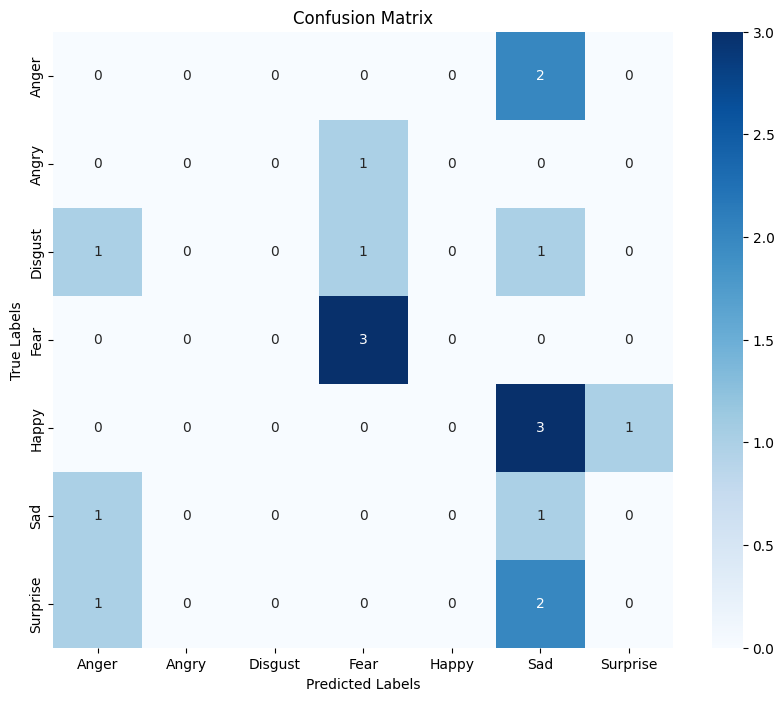

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# Load the saved model
emotion_model = load_model('/content/drive/MyDrive/emotion_recognition_mobilenet_model.h5')

# Define the emotion labels
emotion_labels = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Function to preprocess each frame for the model
def preprocess_frame(frame):
    frame = cv2.resize(frame, (48, 48))  # Resize to model input size
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = frame / 255.0  # Normalize to [0,1]
    frame = np.expand_dims(frame, axis=0)  # Add batch dimension
    return frame

# Function to extract frames from a GIF or WebP file
def extract_frames(file_path):
    frames = []
    file = Image.open(file_path)
    try:
        while True:
            frame = file.convert("RGB")
            frame = np.array(frame)
            frames.append(frame)
            file.seek(file.tell() + 1)
    except EOFError:
        pass  # End of frames
    return frames

# List of file paths with their corresponding true labels
file_paths = [
    ('/content/drive/MyDrive/a1.webp', "Anger"),
    ('/content/drive/MyDrive/a2.webp', "Anger"),
    ('/content/drive/MyDrive/a3.webp', "Anger"),
    ('/content/drive/MyDrive/h1.webp', "Happy"),
    ('/content/drive/MyDrive/h2.webp', "Happy"),
    ('/content/drive/MyDrive/h3.webp', "Happy"),
    ('/content/drive/MyDrive/fear.webp', "Fear"),
    ('/content/drive/MyDrive/fear1.webp', "Fear"),
    ('/content/drive/MyDrive/fear2.webp', "Fear"),
    ('/content/drive/MyDrive/d1.gif', "Disgust"),
    ('/content/drive/MyDrive/d2.gif', "Disgust"),
    ('/content/drive/MyDrive/d3.gif', "Disgust"),
    ('/content/drive/MyDrive/d4.gif', "Sad"),
    ('/content/drive/MyDrive/d5.gif', "Disgust"),
    ('/content/drive/MyDrive/happy1.gif', "Happy"),
    ('/content/drive/MyDrive/happy2.gif', "Surprise"),
    ('/content/drive/MyDrive/sad1.gif', "Sad"),
    ('/content/drive/MyDrive/surprise2.gif', "Surprise"),
    ('/content/drive/MyDrive/test_video2.gif', "Sad"),
    ('/content/drive/MyDrive/test_video3.gif', "Angry"),
    ('/content/drive/MyDrive/test_video4.gif', "Surprise")
    # Add more files as needed
]

y_true = []
y_pred = []

# Process each file
for file_path, true_label in file_paths:
    frames = extract_frames(file_path)
    file_predictions = []

    # Make predictions for each frame
    for frame in frames:
        processed_frame = preprocess_frame(frame)
        prediction = emotion_model.predict(processed_frame)
        predicted_label = emotion_labels[np.argmax(prediction)]
        file_predictions.append(predicted_label)

    # Aggregate predictions using majority vote
    final_prediction = max(set(file_predictions), key=file_predictions.count)
    y_true.append(true_label)
    y_pred.append(final_prediction)

# Calculate final accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Final Accuracy: {accuracy * 100:.2f}%")
# Adjust classification report and confusion matrix based on unique labels in y_true
unique_labels = np.unique(y_true)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=unique_labels))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=unique_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


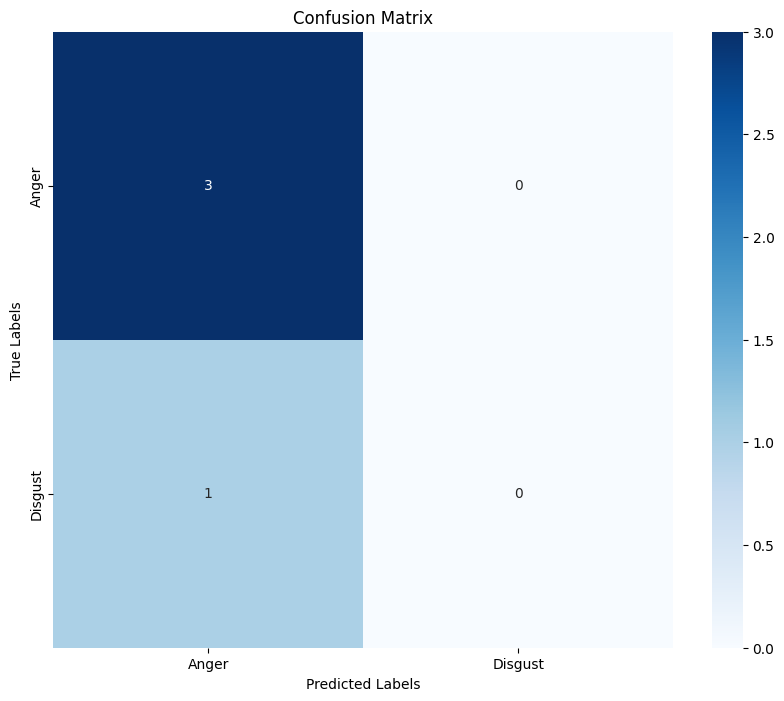

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the model
emotion_model = load_model('/content/drive/MyDrive/emotion_recognition_mobilenet_model.h5')

# Define the emotion labels
emotion_labels = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Augmentation generator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Function to preprocess each frame for the model
def preprocess_frame(frame):
    frame = cv2.resize(frame, (48, 48))
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = frame / 255.0
    frame = np.expand_dims(frame, axis=0)
    return frame

# Function to extract frames from a GIF or WebP
def extract_frames(file_path):
    frames = []
    img = Image.open(file_path)
    try:
        while True:
            frame = img.convert("RGB")
            frame = np.array(frame)
            frames.append(frame)
            img.seek(img.tell() + 1)
    except EOFError:
        pass
    return frames

# Define the list of files and labels
gif_files = [
    ('/content/drive/MyDrive/a1.webp', "Anger"),
    ('/content/drive/MyDrive/a2.webp', "Anger"),
    ('/content/drive/MyDrive/a3.webp', "Anger"),
    ('/content/drive/MyDrive/d1.gif', "Disgust"),


]

y_true = []
y_pred = []

# Process each file
for file_path, true_label in gif_files:
    frames = extract_frames(file_path)
    gif_predictions = []

    for frame in frames:
        processed_frame = preprocess_frame(frame)

        # Apply augmentation on frames for more training variety
        for augmented_frame in datagen.flow(processed_frame, batch_size=1):
            prediction = emotion_model.predict(augmented_frame)
            predicted_label = emotion_labels[np.argmax(prediction)]
            gif_predictions.append(predicted_label)
            break

    # Majority vote for final prediction
    final_prediction = max(set(gif_predictions), key=gif_predictions.count)
    y_true.append(true_label)
    y_pred.append(final_prediction)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Final Accuracy: {accuracy * 100:.2f}%")

# Classification report

unique_labels = np.unique(y_true)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=unique_labels))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=unique_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Prediction: [[[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  ...

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]]]
Prediction shape: (1, 48, 48, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediction: [[[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  ...

  [[0. 0. 0.]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


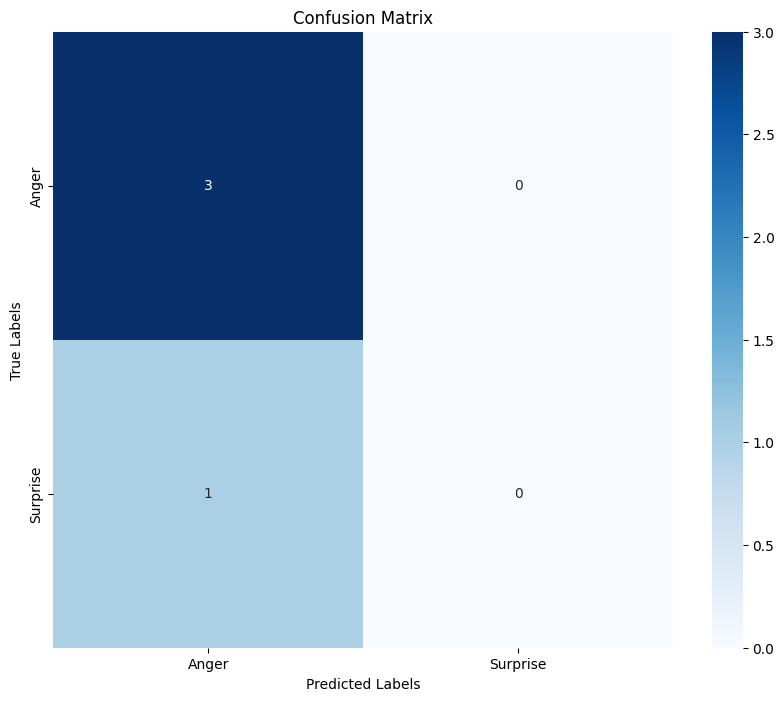

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Load or build the model with Dropout and Batch Normalization
def build_model_with_regularization():
    model = Sequential([
        # Assuming MobileNet or similar base model (replace with your exact model if needed)
        Dropout(0.3),
        BatchNormalization(),
        # Add other layers as needed or use an existing model
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

emotion_model = build_model_with_regularization()

# Define emotion labels (modify as needed based on your specific classes)
emotion_labels = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Improved data augmentation with more variations
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5],
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Learning rate scheduler and model checkpoint
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=1e-6)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# Preprocessing function
def preprocess_frame(frame):
    frame = cv2.resize(frame, (48, 48))  # Ensure this size matches your model input size
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = frame / 255.0  # Normalize pixel values
    frame = np.expand_dims(frame, axis=0)
    return frame

# Extract frames from GIF or WebP file
def extract_frames(file_path):
    frames = []
    img = Image.open(file_path)
    try:
        while True:
            frame = img.convert("RGB")
            frame = np.array(frame)
            frames.append(frame)
            img.seek(img.tell() + 1)
    except EOFError:
        pass
    return frames

# Define list of files and labels (replace with your file paths and labels)
gif_files = [
    ('/content/drive/MyDrive/a1.webp', "Anger"),
    ('/content/drive/MyDrive/a2.webp', "Anger"),
    ('/content/drive/MyDrive/a3.webp', "Anger"),
    ('/content/drive/MyDrive/test_video4.gif', "Surprise")
]

y_true = []
y_pred = []

# Predict on augmented frames
for file_path, true_label in gif_files:
    frames = extract_frames(file_path)
    gif_predictions = []
    for frame in frames:
        processed_frame = preprocess_frame(frame)
        for augmented_frame in datagen.flow(processed_frame, batch_size=1):
            prediction = emotion_model.predict(augmented_frame)
            print(f"Prediction: {prediction}")  # Check the prediction output
            print(f"Prediction shape: {prediction.shape}")  # Check prediction shape

            # Check if the predicted index is within the bounds of the labels
            pred_index = np.argmax(prediction)
            if pred_index < len(emotion_labels):
                predicted_label = emotion_labels[pred_index]
            else:
                print(f"Warning: Predicted index {pred_index} is out of bounds for emotion labels.")
                predicted_label = "Unknown"  # Assign a default or unknown label if index is out of range

            gif_predictions.append(predicted_label)
            break  # Use only one augmented frame for prediction

    # Majority vote for final prediction
    final_prediction = max(set(gif_predictions), key=gif_predictions.count)
    y_true.append(true_label)
    y_pred.append(final_prediction)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Final Accuracy: {accuracy * 100:.2f}%")

# Classification report
unique_labels = np.unique(y_true)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=unique_labels))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=unique_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
